<a href="https://colab.research.google.com/github/piroyon/mbgd-pipeline/blob/main/mbgd_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

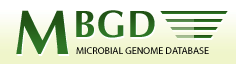<br>
MBGD is a database for comparative analysis of completely sequenced microbial genomes, the number of which is now growing rapidly. The aim of MBGD is to facilitate comparative genomics from various points of view such as ortholog identification, paralog clustering, motif analysis and gene order comparison. References: [J Mol Biol. 2025 Jan 16:168957](https://www.sciencedirect.com/science/article/pii/S0022283625000233)

In [ ]:
#@title Install dependencies
import os
import sys
import shutil
import subprocess
from google.colab import drive
import glob
import re
import math
import pandas as pd
def clone_repo(repo_url, repo_name):
    target_path = f"/content/{repo_name}"
    bin_path = f"{target_path}/bin"
    if not os.path.exists(target_path):
        !git clone {repo_url} {target_path}
    else:
        print(f"'{target_path}' already exists, skipping clone.")
    os.environ["PATH"] = f"{bin_path}:{os.environ['PATH']}"
    print(f"Added to PATH: {bin_path}")
def install_from_tar(download_url, binary_name, archive_name="temp.tar.gz", extract_dir="/content"):
    archive_path = f"/content/{archive_name}"
    if binary_name is None or str(binary_name).lower() == "none":
        print(f"Downloading and extracting to {extract_dir}...")
        !wget -q -P /content {download_url}
        !tar -xf {archive_path} -C {extract_dir}
        if os.path.exists(archive_path):
            !rm {archive_path}
        print(f"Successfully extracted archive to {extract_dir}")
    else:
        target_binary_path = f"/usr/local/bin/{binary_name}"

        if not os.path.exists(target_binary_path):
            !wget -q -P /content {download_url}
            !tar -xf {archive_path} -C /usr/local/bin

            if os.path.exists(archive_path):
                !rm {archive_path}
            print(f"Successfully installed '{binary_name}' to /usr/local/bin")
        else:
            print(f"'{target_binary_path}' already exists, skipping installation.")

clone_repo("https://github.com/mbgd-prj/domclust", "domclust")
clone_repo("https://github.com/piroyon/mbgd-pipeline", "mbgd-pipeline")
%cd /content/domclust
!sh ./configure --prefix=/usr/local
!make install
%cd /content
install_from_tar("https://github.com/bbuchfink/diamond/releases/download/v2.2.5/diamond-linux64.tar.gz", "diamond", archive_name="diamond-linux64.tar.gz")
install_from_tar("https://mbgd.nibb.ac.jp/CGB/dist/CGB.tgz", "none", archive_name="CGB.tgz", extract_dir="/content")
!cp /content/CGB/lib/CompareMap.jar /content/mbgd-pipeline/lib/
!cp /content/CGB/bin/corealign /content/mbgd-pipeline/bin/
!apt update -qq
!apt install -y openjdk-11-jre xvfb libwww-perl libjson-perl
candidates = glob.glob("/usr/lib/jvm/java-11-openjdk-*/bin/java")
if not candidates:
    raise RuntimeError("Java 11 JRE not found")
JAVA = candidates[0]
print("Using Java:", JAVA)
os.system(f"{JAVA} -version")

# Step-by-step orhtology analysis using MBGD

In [ ]:
# @title Google Drive Mount & Workspace Setup { display-mode: "form" }

# --- Form Configuration ---
# @markdown ### Workspace Configuration
# @markdown Enter the folder name to be created directly under MyDrive:
WORK_DIR = "ccc" # @param {type:"string"}

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Build target path and create directory if it does not exist
drive_root = "/content/drive/MyDrive"
target_dir = os.path.join(drive_root, WORK_DIR)

if not os.path.exists(target_dir):
    os.makedirs(target_dir, exist_ok=True)
    print(f"Created directory: {target_dir}")
else:
    print(f"Using existing directory: {target_dir}")

# 3. Change current working directory to target directory
os.chdir(target_dir)
print(f"Current working directory set to: {os.getcwd()}")

In [ ]:
# @title Project Configuration { display-mode: "form" }
# @markdown ### Project Setting
# @markdown Enter a project identifier prefix (e.g., `bacillus_analysis`):
output_prefix = "bacil" # @param {type:"string"}

# @markdown ---
# @markdown ### MBGD Species Codes (3-5 characters each)
# @markdown * Enter comma-separated MBGD species codes.
# @markdown * You can look up the codes under "**Search for spid, taxid, etc.**" menu on the MBGD API (https://mbgdapi.nibb.ac.jp).
# @markdown * **Leave blank if using custom data ONLY**
raw_species_input = "bsu, ban, bce" # @param {type:"string"}

# --- Process Project Configuration ---
output_prefix = output_prefix.strip()
valid_strings = []

if not output_prefix:
    print("Error: 'output_prefix' cannot be empty.", file=sys.stderr)
else:
    # Process MBGD species codes if provided
    if raw_species_input.strip():
        raw_list = [s.strip() for s in raw_species_input.split(",") if s.strip()]
        for code in raw_list:
            if re.match(r"^[a-zA-Z0-9]{3,5}$", code):
                valid_strings.append(code)
            else:
                print(f"Warning: Invalid species code '{code}' ignored (must be 3-5 alphanumeric chars).")

    print(f"Project Prefix: '{output_prefix}'")
    print(f"Initial MBGD Species Codes: {valid_strings}")

In [ ]:
# @title Fetch Genome Data from MBGD { display-mode: "form" }
# @markdown **[Note]** If you are NOT using MBGD data (i.e., running the analysis with custom data ONLY), please **skip this cell** and proceed to the next Cell.
# --- Execute MBGD Retrieval ---
if 'valid_strings' in globals() and valid_strings and 'output_prefix' in globals() and output_prefix:

    genetab_file = f"{output_prefix}.genetab"
    faa_file = f"{output_prefix}.faa"

    # 1. Clean up existing output files before execution
    for target in [genetab_file, faa_file]:
        if os.path.exists(target):
            os.remove(target)
            print(f"Removed existing file: '{target}'")

    # 2. Resolve path for mbgd2genetab.pl
    script_path = shutil.which("mbgd2genetab.pl") or "./mbgd2genetab.pl"

    # 3. Build command
    outname_opt = f"-outname={output_prefix}"
    command = ["perl", script_path, outname_opt] + valid_strings

    print(f"Executing: {' '.join(command)}")

    # 4. Execute script
    result = subprocess.run(command, text=True, capture_output=True, env=os.environ)

    if result.stdout:
        print("\n--- Output ---")
        print(result.stdout)

    if result.stderr:
        print("\n--- Error Log ---")
        print(result.stderr, file=sys.stderr)

    # 5. Verify generated files & show head preview
    print("\n=== MBGD Generated Files Check ===")
    for target in [genetab_file, faa_file]:
        if os.path.exists(target):
            print(f"\nSuccessfully generated: '{target}'")
            print(f"--- Preview of '{target}' (First 10 lines) ---")
            with open(target, 'r') as f:
                for _ in range(10):
                    line = f.readline()
                    if not line:
                        break
                    print(line, end="")
        else:
            print(f"Error: Expected file '{target}' was not created.", file=sys.stderr)

else:
    print("Skipped or Error: No MBGD species codes specified in the above cell.", file=sys.stderr)

In [ ]:
# @title [Optional] Merge Custom Data (FASTA + GFF) { display-mode: "form" }
# --- Form Configuration ---
# @markdown ### Merge Custom FASTA and GFF Files
# @markdown *  Enter the folder path relative to your current workspace (`MyDrive/<WORK_DIR>`) containing pairs of `.fasta` (or `.fa`, `.faa`) and `.gff`:
# @markdown *  *(Example: `my_data` or `custom_species`)*
# @markdown *  The string preceding the file extension is used as the species code. Do not include a period before the file extension
CUSTOM_DATA_DIR = "HPG00002" # @param {type:"string"}


# --- Process Custom Data ---
if 'output_prefix' in globals() and output_prefix:

    combined_genetab = f"{output_prefix}.genetab"
    combined_faa = f"{output_prefix}.faa"

    # Initialize valid_strings if Cell 2.2 was skipped
    if 'valid_strings' not in globals() or valid_strings is None:
        valid_strings = []

    # Directly use the relative path from the current workspace directory
    target_dir = CUSTOM_DATA_DIR.strip()

    gff2genetab_pl = shutil.which("gff2genetab_c.pl") or "gff2genetab_c.pl"
    prep_fasta_pl = shutil.which("prepare_fastafile.pl") or "prepare_fastafile.pl"

    if not os.path.exists(target_dir):
        print(f"Warning: Folder '{target_dir}' does not exist in current workspace ({os.getcwd()}).", file=sys.stderr)
    else:
        # 1. Find FASTA files recursively inside the target directory
        fasta_files = (
            glob.glob(os.path.join(target_dir, "**", "*.fasta"), recursive=True) +
            glob.glob(os.path.join(target_dir, "**", "*.fa"), recursive=True) +
            glob.glob(os.path.join(target_dir, "**", "*.faa"), recursive=True)
        )

        # 2. Pair with corresponding GFF files
        valid_pairs = []
        for fpath in fasta_files:
            base_path, _ = os.path.splitext(fpath)
            gff_candidate = f"{base_path}.gff"
            gff3_candidate = f"{base_path}.gff3"

            if os.path.exists(gff_candidate):
                valid_pairs.append((fpath, gff_candidate))
            elif os.path.exists(gff3_candidate):
                valid_pairs.append((fpath, gff3_candidate))
            else:
                print(f"Warning: Missing matching .gff file for '{os.path.basename(fpath)}'. Skipping.")

        if not valid_pairs:
            print(f"No valid FASTA + GFF pairs found in '{target_dir}'.")
        else:
            added_species = []

            for fasta_path, gff_path in valid_pairs:
                code = os.path.splitext(os.path.basename(fasta_path))[0]

                # Validate species code length (3 to 5 characters)
                if code in valid_strings:
                    print(f"Warning: Code '{code}' already exists in species list. Skipping.")
                    continue

                print(f"\nProcessing paired custom data for species code '{code}'...")

                # Output temporary files directly to current working directory
                tmp_genetab = f"{code}.genetab"
                tmp_faa = f"{code}.faa"

                # Convert GFF -> .genetab
                !{gff2genetab_pl} -tag=locus_tag {gff_path} > {tmp_genetab}

                # Convert FASTA -> .faa
                !{prep_fasta_pl} -SPNAME={code} {fasta_path} > {tmp_faa}

                # Append to combined dataset (Creates file if missing, Appends if exists)
                if os.path.exists(tmp_genetab) and os.path.exists(tmp_faa):
                    mode_genetab = "a" if os.path.exists(combined_genetab) else "w"
                    with open(tmp_genetab, "r") as src, open(combined_genetab, mode_genetab) as dst:
                        dst.write(src.read())

                    mode_faa = "a" if os.path.exists(combined_faa) else "w"
                    with open(tmp_faa, "r") as src, open(combined_faa, mode_faa) as dst:
                        dst.write(src.read())

                    # Clean up temporary individual files
                    #os.remove(tmp_genetab)
                    #os.remove(tmp_faa)

                    added_species.append(code)
                    print(f"Successfully processed and merged '{code}'.")
                else:
                    print(f"Error: Conversion failed for '{code}'.", file=sys.stderr)

            # Update valid_strings list for downstream cells
            valid_strings.extend(added_species)

            print(f"\n=== Custom Data Merge Summary ===")
            print(f"Added Custom Species: {added_species}")
            print(f"Total Species List (valid_strings): {valid_strings}")

else:
    print("Error: 'output_prefix' is missing. Please run Cell 2.1 first.", file=sys.stderr)

In [ ]:
# @title Run DIAMOND Database Creation & BLASTP { display-mode: "form" }

# --- DIAMOND Execution ---
if 'output_prefix' in globals() and output_prefix:

    # 1. Define filenames based on output_prefix
    input_faa = f"{output_prefix}.faa"
    db_name = output_prefix  # DIAMOND automatically appends .dmnd
    output_file = f"{output_prefix}.diamondout"

    # Check if input FASTA file exists
    if not os.path.exists(input_faa):
        print(f"Error: Input file '{input_faa}' not found in current directory.", file=sys.stderr)
    else:
        # 2. Command 1: makedb
        cmd_makedb = ["diamond", "makedb", "--in", input_faa, "--db", db_name]
        print(f"Executing: {' '.join(cmd_makedb)}")
        res_makedb = subprocess.run(cmd_makedb, text=True, capture_output=True, env=os.environ)

        if res_makedb.stdout:
            print(res_makedb.stdout)
        if res_makedb.stderr:
            print(res_makedb.stderr, file=sys.stderr)

        # 3. Command 2: blastp
        if res_makedb.returncode == 0:
            cmd_blastp = [
                "diamond", "blastp",
                "--query", input_faa,
                "--db", db_name,
                "--evalue", "0.001",
                "--out", output_file
            ]
            print(f"\nExecuting: {' '.join(cmd_blastp)}")
            res_blastp = subprocess.run(cmd_blastp, text=True, capture_output=True, env=os.environ)

            if res_blastp.stdout:
                print(res_blastp.stdout)
            if res_blastp.stderr:
                print(res_blastp.stderr, file=sys.stderr)

            if res_blastp.returncode == 0:
                print(f"\nDIAMOND process completed successfully. Output saved to '{output_file}'.")
else:
    print("Error: 'output_prefix' is missing. Please run the input form cell first.", file=sys.stderr)

In [ ]:
# @title Create a homfile from the diamond output file.{ display-mode: "form" }
# --- Create Homfile ---
if 'output_prefix' in globals() and output_prefix:

    # 1. Define filenames based on output_prefix
    diamond_out = f"{output_prefix}.diamondout"
    hom_out = f"{output_prefix}.hom"

    # Check if DIAMOND output file exists
    if not os.path.exists(diamond_out):
        print(f"Error: Input file '{diamond_out}' not found.", file=sys.stderr)
    else:
        # 2. Resolve full path of script.pl using shutil.which
        script_path = shutil.which("blast2homfile.pl") or "./blast2homfile.pl"

        # 3. Execute Perl script with stdout redirection
        print(f"Executing: {script_path} {diamond_out} > {hom_out}")

        # Execute shell command using full path
        !{script_path} {diamond_out} > {hom_out}

        # Check if output file was created successfully and print preview
        if os.path.exists(hom_out):
            print(f"\nSuccessfully generated homfile: '{hom_out}'\n")

            # Preview the first 10 lines of the generated file
            print(f"--- Preview of '{hom_out}' (First 10 lines) ---")
            !head -n 10 {hom_out}
        else:
            print(f"Error: Failed to create '{hom_out}'", file=sys.stderr)

else:
    print("Error: 'output_prefix' is missing. Please run the input form cell first.", file=sys.stderr)

In [ ]:
# @title Domain Clustering with DomClust { display-mode: "form" }

# --- Run DomClust ---
if 'output_prefix' in globals() and output_prefix:

    # 1. Define input/output filenames based on output_prefix
    hom_file = f"{output_prefix}.hom"
    genetab_file = f"{output_prefix}.genetab"
    domclust_out = f"{output_prefix}_domclust.out"

    # Check if required input files exist
    if not os.path.exists(hom_file):
        print(f"Error: Input file '{hom_file}' not found.", file=sys.stderr)
    elif not os.path.exists(genetab_file):
        print(f"Error: Input file '{genetab_file}' not found.", file=sys.stderr)
    else:
        # 2. Resolve full path of domclust using shutil.which
        domclust_bin = shutil.which("domclust") or "domclust"

        # 3. Execute domclust with stdout redirection
        print(f"Executing: {domclust_bin} {hom_file} {genetab_file} > {domclust_out}")

        # Execute shell command using full path
        !{domclust_bin} {hom_file} {genetab_file} > {domclust_out}

        # Check if output file was created successfully and print preview
        if os.path.exists(domclust_out):
            print(f"\nSuccessfully generated DomClust output: '{domclust_out}'\n")

            # Preview the first 10 lines of the generated file
            print(f"--- Preview of '{domclust_out}' (First 10 lines) ---")
            !head -n 10 {domclust_out}
        else:
            print(f"Error: Failed to create '{domclust_out}'", file=sys.stderr)

else:
    print("Error: 'output_prefix' is missing. Please run the input form cell first.", file=sys.stderr)

In [ ]:
# @title Summary Statistics of DomClust Output { display-mode: "form" }
# --- Summary Statistics calculation ---
if 'output_prefix' in globals() and output_prefix:

    domclust_out = f"{output_prefix}_domclust.out"

    if not os.path.exists(domclust_out):
        print(f"Error: Output file '{domclust_out}' not found.", file=sys.stderr)
    else:
        clusters = []
        current_cluster = []

        # Parse DomClust block format
        with open(domclust_out, "r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue

                # Check for Cluster header block
                if line.startswith("Cluster "):
                    if current_cluster:
                        clusters.append(current_cluster)
                        current_cluster = []
                else:
                    # Collect member line (e.g., "bsu:BSU_34610 1 417")
                    current_cluster.append(line)

            # Append the last cluster block
            if current_cluster:
                clusters.append(current_cluster)

        total_clusters = len(clusters)

        if total_clusters > 0:
            sizes = [len(c) for c in clusters]
            singletons = sum(1 for s in sizes if s == 1)
            multi_gene_clusters = total_clusters - singletons
            max_size = max(sizes)
            avg_size = sum(sizes) / total_clusters

            # Display statistics summary
            print(f"=== DomClust Summary Statistics ({domclust_out}) ===")
            print(f"Total Clusters         : {total_clusters}")
            print(f"Multi-element Clusters : {multi_gene_clusters}")
            print(f"Singleton Clusters     : {singletons}")
            print(f"Max Cluster Size       : {max_size}")
            print(f"Average Cluster Size   : {avg_size:.2f}")
        else:
            print(f"No clusters found in '{domclust_out}'.")

else:
    print("Error: 'output_prefix' is missing. Please run the input form cell first.", file=sys.stderr)

In [ ]:
# @title [Optional] Phylogenetic profile (presence or absence) analysis. { display-mode: "form" }
domclust_out_o5 = f"{output_prefix}_domclust.o5"
!{domclust_bin} -o5 {hom_file} {genetab_file} > {domclust_out_o5}
if os.path.exists(domclust_out_o5):
            print(f"\nSuccessfully generated DomClust o5 output: '{domclust_out_o5}'\n")
df = pd.read_table(domclust_out_o5, sep='\t', index_col=0)
countmat = df.map(lambda x: len(x.split(' ')) if (not pd.isna(x)) else 0)
count_matrix_file = f"{output_prefix}_count_matrix.csv"
countmat.to_csv(count_matrix_file)
if os.path.exists(count_matrix_file):
            print(f"\nSuccessfully saved Count matrix: '{count_matrix_file}'\n")
print("Count matrix")
print(countmat)


#print("\nFilterd ortholog groups:\npresence: UG00001, absence: bce")
#print(countmat.query('bce == 0 and UG00001 == 1'))


In [ ]:
# @title Core Gene Synteny Analysis with CoreAligner { display-mode: "form" }

# --- Run CoreAligner ---
if 'output_prefix' in globals() and output_prefix:

    # 1. Define input/output filenames based on output_prefix
    domclust_out = f"{output_prefix}_domclust.out"
    genetab_file = f"{output_prefix}.genetab"
    coaln_out = f"{output_prefix}.coaln"

    # Check if required input files exist
    if not os.path.exists(domclust_out):
        print(f"Error: Input file '{domclust_out}' not found.", file=sys.stderr)
    elif not os.path.exists(genetab_file):
        print(f"Error: Input file '{genetab_file}' not found.", file=sys.stderr)
    else:
        # 2. Resolve full path of corealign using shutil.which
        corealign_bin = shutil.which("corealign") or "corealign"

        # 3. Execute corealign
        cmd_str = f"{corealign_bin} -domclustIn {domclust_out} {genetab_file} -out={coaln_out}"
        print(f"Executing: {cmd_str}")

        # Execute shell command
        !{corealign_bin} -domclustIn {domclust_out} {genetab_file} -out={coaln_out}

        # Check if output file was created successfully and print head preview
        if os.path.exists(coaln_out):
            print(f"\nSuccessfully generated CoreAligner output: '{coaln_out}'\n")

            # Preview the first 10 lines of the generated .coaln file
            print(f"--- Preview of '{coaln_out}' (First 10 lines) ---")
            !head -n 10 {coaln_out}
        else:
            print(f"Error: Failed to create '{coaln_out}'", file=sys.stderr)

else:
    print("Error: 'output_prefix' is missing. Please run the input form cell first.", file=sys.stderr)

Ignore any warnings

In [ ]:
# @title Synteny Map Visualization with CompareMap { display-mode: "form" }
import glob
from IPython.display import Image, display

# --- Run CompareMap Visualization ---
if 'output_prefix' in globals() and output_prefix:

    # 1. Define input/output filenames based on output_prefix
    coaln_out = f"{output_prefix}.coaln"
    genetab_file = f"{output_prefix}.genetab"
    png_out = f"{output_prefix}_CompareMap.png"

    # Define path to CompareMap.jar
    jar_path = "/content/mbgd-pipeline/lib/CompareMap.jar"

    # 2. Find Java 11 JRE binary path
    candidates = glob.glob("/usr/lib/jvm/java-11-openjdk-*/bin/java")
    if not candidates:
        print("Error: Java 11 JRE not found in /usr/lib/jvm/", file=sys.stderr)
        JAVA = None
    else:
        JAVA = candidates[0]

    # Check if required files and Java exist
    if JAVA is None:
        pass
    elif not os.path.exists(coaln_out):
        print(f"Error: Input file '{coaln_out}' not found.", file=sys.stderr)
    elif not os.path.exists(genetab_file):
        print(f"Error: Input file '{genetab_file}' not found.", file=sys.stderr)
    elif not os.path.exists(jar_path):
        print(f"Error: JAR file '{jar_path}' not found.", file=sys.stderr)
    else:
        # 3. Execute CompareMap in headless mode using specific Java 11
        print(f"Using Java executable: {JAVA}")
        cmd_str = f"xvfb-run -a {JAVA} -jar {jar_path} {coaln_out} {genetab_file} -outfile={png_out}"
        print(f"Executing: {cmd_str}")

        # Execute shell command with variable expansion
        !xvfb-run -a {JAVA} -jar {jar_path} {coaln_out} {genetab_file} -outfile={png_out}

        # 4. Check if output PNG was created and display in notebook
        if os.path.exists(png_out):
            print(f"\nSuccessfully generated visualization map: '{png_out}'\n")
            display(Image(filename=png_out))
        else:
            print(f"Error: Failed to create '{png_out}'", file=sys.stderr)

else:
    print("Error: 'output_prefix' is missing. Please run the input form cell first.", file=sys.stderr)